<a href="https://colab.research.google.com/github/asmita-durugkar/ml_learning/blob/main/Linearregression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [27]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn import linear_model,datasets,model_selection

In [11]:
data = datasets.load_diabetes()
X, y = data.data, data.target #Load the diabetes dataset, divided into X data and y features
X_df = pd.DataFrame(X, columns=data.feature_names) #I automatically generated generic column names like feature_0, feature_1, etc. This was because X is initially a NumPy array, which doesn't inherently store column names.
X_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
dtypes: float64(10)
memory usage: 34.7 KB


In [ ]:
selected=X[:,2] #selecting 3 feature bmi
selected

In [ ]:
selected=selected.reshape(-1,1) #reshape to 2d array
selected

In [22]:
X_train, X_test, y_train, y_test = model_selection.train_test_split(selected, y, test_size=0.2)
#This splits your dataset into two portions: 80% for training the model and 20% for testing its performance.
#Splitting ensures you can test how well your model generalizes to unseen data (X_test, y_test) rather than just memorizing the data it learned from.


In [23]:
#select model adn fit it with training data
model=linear_model.LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

In [25]:
pred=model.predict(X_test)

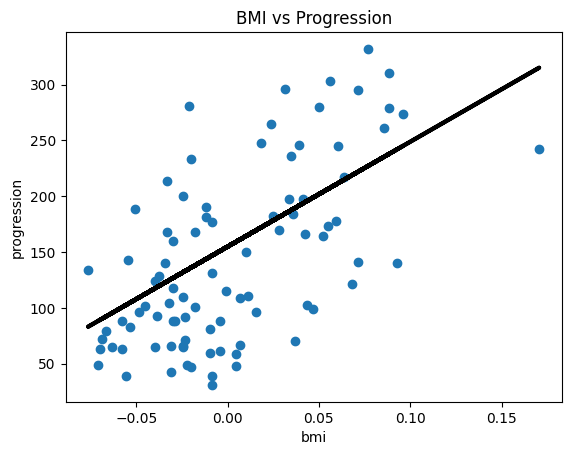

In [39]:
plt.scatter(X_test,y_test)
plt.title('BMI vs Progression')
plt.xlabel('bmi')
plt.ylabel('progression')
plt.plot(X_test,pred,color='black',linewidth=3)
plt.show()

# Core insights
Positive Correlation: There is a clear upward trend from left to right. This means higher BMI is linked to increased diabetes progression over one year.

Moderate Predictive Power: While the linear regression line safely captures the general upward trend, many data points sit far above or below it. This proves that while BMI is a significant risk factor, it doesn't tell the whole story—other biological variables are also at play.

Data Scale Note: You will notice the BMI values on the x-axis range from roughly -0.1 to 0.15. This is because the dataset from scikit-learn comes mean-centered and scaled, meaning the numbers represent how far a patient's BMI deviates from the average, rather than showing raw BMI numbers (like 25 or 30)